# 프로젝트 : mini BERT 만들기


- 공통 설정
  - corpus: heegyu/namuwiki-extracted
  - tokenizer: SentencePiece BPE
  - vocab size: 8000 + BERT special tokens 7 = 8007
  - SentencePiece input_sentence_size: 200000
  - max sequence length: 128
  - model size: 약 1.03M parameters
  - optimizer: AdamW
  - learning rate: 5e-4
  - batch size: 8
  - MLM mask ratio: 15%
  - MLM replacement rule: 80% [MASK], 10% random token, 10% original token
  - NSP positive/negative ratio: 50% / 50%

- 추가실험
  - 실험 1: 빠른 실행 검증
    - BERT_PRETRAIN_COUNT = 4096
    - EPOCHS = 10
    - 결과:
      total loss: 8.6238 -> 5.3408
      MLM loss  : 7.9280 -> 4.9231
      NSP loss  : 0.6958 -> 0.4176
    - 해석:
      빠르게 전체 파이프라인 동작을 확인하기 위한 실험.
      작은 데이터셋이라 train loss가 낮게 내려가지만 과적합 가능성이 있음.

  - 실험 2: 기본 실험
    - BERT_PRETRAIN_COUNT = 20000
    - EPOCHS = 10
    - 결과:
      total loss: 8.1807 -> 6.2734
      MLM loss  : 7.4868 -> 5.8139
      NSP loss  : 0.6939 -> 0.4595
      MLM accuracy: 20.21%
      NSP accuracy: 90.68%
    - 해석:
      4096개 실험보다 데이터 다양성이 커서 최종 실험 기준으로 사용하기 적합함.

  - 실험 3: epoch 증가 실험
    - BERT_PRETRAIN_COUNT = 20000
    - EPOCHS = 15
    - 결과:
      total loss: 8.1885 -> 5.9051
      MLM loss  : 7.4944 -> 5.6987
      NSP loss  : 0.6941 -> 0.2064
      MLM accuracy: 21.51%
      NSP accuracy: 97.52%
    - 해석:
      train set 기준 성능은 개선되었지만,
      무관한 문장쌍도 True로 예측하는 사례가 있어 NSP 과적합 가능성이 있음.

## Step 0. 환경설정 및 데이터준비

In [65]:
import os, re, sys, time
import json, math
import subprocess
import zipfile
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import sentencepiece as spm
import matplotlib.pyplot as plt
from datasets import load_dataset
from tqdm.auto import tqdm
from pathlib import Path
from torch.utils.data import Dataset, DataLoader

# 기본값은 Colab에서 끊기지 않고 끝까지 도는 빠른 실행 모드입니다.
# 그래프가 선으로 보이도록 epoch 기본값은 3으로 설정했습니다.
# 전체 데이터로 오래 학습하려면 아래 값을 "0"으로 바꾸면 됩니다.
os.environ.setdefault("BERT_PRETRAIN_FAST_RUN", "0")         # "1"이면 빠른 실행: 코퍼스 일부만 사용 /"0" 전체
os.environ.setdefault("BERT_PRETRAIN_MAX_LINES", "20000")    # 빠른 실행 모드에서 사용할 최대 라인 수
os.environ.setdefault("BERT_PRETRAIN_COUNT", "20000")        # pretrain 데이터 생성/학습에서 사용할 샘플 개수
os.environ.setdefault("BERT_PRETRAIN_EPOCHS", "10")          # 학습 epoch 수
os.environ.setdefault("BERT_PRETRAIN_BATCH_SIZE", "8")       # 학습 batch size
os.environ.setdefault("BERT_PRETRAIN_SP_VOCAB_SIZE", "8000") # SentencePiece 기본 vocab size

# 패키지 설치
subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q",
    "sentencepiece", "tqdm", "torchinfo"
])

# ------------------------------------------------------------
# 기본 경로 및 실행 옵션
# ------------------------------------------------------------
BASE_DIR = Path("/content") if Path("/content").exists() else Path.cwd()
os.chdir(BASE_DIR)

DATA_DIR = BASE_DIR / "data"
MODEL_DIR = BASE_DIR / "models"
WORK_DIR = BASE_DIR / "work"

for path in (DATA_DIR, MODEL_DIR, WORK_DIR):
  path.mkdir(parents=True, exist_ok=True)


In [121]:
# ------------------------------------------------------------
# 실험 설정 강제 변경
# ------------------------------------------------------------

os.environ["BERT_PRETRAIN_FAST_RUN"] = "0"
os.environ["BERT_PRETRAIN_MAX_LINES"] = "200000"
os.environ["BERT_PRETRAIN_COUNT"] = "20000"
os.environ["BERT_PRETRAIN_EPOCHS"] = "15"  # 10 -> 15 ( 20000인 경우)
os.environ["BERT_PRETRAIN_BATCH_SIZE"] = "8"
os.environ["BERT_PRETRAIN_SP_VOCAB_SIZE"] = "8000"

print("FAST_RUN:", os.environ["BERT_PRETRAIN_FAST_RUN"])
print("MAX_LINES:", os.environ["BERT_PRETRAIN_MAX_LINES"])
print("COUNT:", os.environ["BERT_PRETRAIN_COUNT"])
print("EPOCHS:", os.environ["BERT_PRETRAIN_EPOCHS"])
print("BATCH_SIZE:", os.environ["BERT_PRETRAIN_BATCH_SIZE"])
print("SP_VOCAB_SIZE:", os.environ["BERT_PRETRAIN_SP_VOCAB_SIZE"])



FAST_RUN: 0
MAX_LINES: 200000
COUNT: 20000
EPOCHS: 15
BATCH_SIZE: 8
SP_VOCAB_SIZE: 8000


In [67]:
# 확인
fast_run = int(os.environ.get("BERT_PRETRAIN_FAST_RUN", "0"))
epochs = int(os.environ.get("BERT_PRETRAIN_EPOCHS", "10"))
max_lines = int(os.environ.get("BERT_PRETRAIN_MAX_LINES", "10"))

print("max_lines:", max_lines)
print("fast_run:", fast_run)
print("epochs:", epochs)

max_lines: 200000
fast_run: 0
epochs: 10


## Step 1. Tokenizer 준비

- SentencePiece 모델을 이용해 BERT의 MLM 학습용 데이터를 만드세요.

- 이를 위해 한글 나무 위키 코퍼스로부터 8000의 vocab_size를 갖는 sentencepiece 모델을 만들어 보세요. BERT에 사용되는 주요 특수문자가 vocab에 포함되어야 합니다.

  - 한글 나무위키 코퍼스 사용
  - vocab_size = 8000
  - BERT 주요 특수 토큰 포함: [PAD], [UNK], [BOS], [EOS], [SEP], [CLS], [MASK]

### 1-1. 나무위키 원본 다운로드

In [2]:
# ------------------------------------------------------------
# 나무위키 원본 다운로드
# ------------------------------------------------------------
corpus_path = DATA_DIR / "namuwiki_clean.txt"

if not corpus_path.exists():
    print("Downloading heegyu/namuwiki-extracted...")
    dataset = load_dataset("heegyu/namuwiki-extracted")

    print("Saving extracted text corpus...")

    with open(corpus_path, "w", encoding="utf-8") as out_f:
        for row in tqdm(dataset["train"], desc="Writing corpus"):
            text = row.get("text")

            if text:
                text = text.strip()

                if len(text) >= 20:
                    out_f.write(text)
                    out_f.write("\n\n")

    print("Saved corpus:", corpus_path)
else:
    print("Corpus already exists:", corpus_path)



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

namuwiki_20210301_v3.parquet:   0%|          | 0.00/2.36G [00:00<?, ?B/s]

Generating train split:   0%|          | 0/565293 [00:00<?, ? examples/s]

Saving extracted text corpus...


Writing corpus:   0%|          | 0/565293 [00:00<?, ?it/s]

Saved corpus: /content/data/namuwiki_clean.txt


### 1-2. 빠른 실행 corpus 생성

In [68]:
# ------------------------------------------------------------
# 빠른 실행용 corpus 선택
# ------------------------------------------------------------

# SentencePiece 학습에는 extracted corpus에서 저장한 clean txt를 사용합니다.
corpus_path = DATA_DIR / "namuwiki_clean.txt"

fast_run = os.environ.get("BERT_PRETRAIN_FAST_RUN") == "1"

if fast_run:
    max_lines = int(os.environ.get("BERT_PRETRAIN_MAX_LINES", "20000"))
    run_corpus_path = DATA_DIR / "namuwiki_colab_small.txt"

    if not run_corpus_path.exists():
        print(f"Creating small corpus for fast run: first {max_lines} lines")

        with open(corpus_path, "r", encoding="utf-8") as in_f, \
             open(run_corpus_path, "w", encoding="utf-8") as out_f:
            for i, line in enumerate(in_f):
                if i >= max_lines:
                    break
                out_f.write(line)
else:
    run_corpus_path = corpus_path

os.environ["BERT_PRETRAIN_CORPUS_FILE"] = str(run_corpus_path)

print("corpus_file:", os.environ["BERT_PRETRAIN_CORPUS_FILE"])
print("fast_run:", fast_run)



corpus_file: /content/data/namuwiki_clean.txt
fast_run: False


### 1-3. SentencePiece tokenizer 학습

In [ ]:

# # ------------------------------------------------------------
# # SentencePiece tokenizer 학습 (vocab size는 8000)
# # ------------------------------------------------------------
# sp_vocab_size = int(os.environ.get("BERT_PRETRAIN_SP_VOCAB_SIZE", "8000"))

# # BERT용 특수 토큰 7개: [PAD], [UNK], [BOS], [EOS], [SEP], [CLS], [MASK]
# real_vocab_size = sp_vocab_size + 7

# # 모델명
# if fast_run:
#     model_name = f"namu_{sp_vocab_size}_fast"
# else:
#     model_name = f"namu_{sp_vocab_size}_full"

# model_prefix = DATA_DIR / model_name
# model_path   = DATA_DIR / f"{model_name}.model"

# if not model_path.exists():
#     print(f"Training SentencePiece model: {model_path}")
#     print(f"vocab_size = {real_vocab_size}")

#     spm.SentencePieceTrainer.train(
#         f"--input={run_corpus_path} "
#         f"--model_prefix={model_prefix} "
#         f"--vocab_size={real_vocab_size} "
#         "--model_type=bpe "
#         "--max_sentence_length=999999 "
#         "--pad_id=0 --pad_piece=[PAD] "
#         "--unk_id=1 --unk_piece=[UNK] "
#         "--bos_id=2 --bos_piece=[BOS] "
#         "--eos_id=3 --eos_piece=[EOS] "
#         "--user_defined_symbols=[SEP],[CLS],[MASK] "
#         "--hard_vocab_limit=false"
#     )
# else:
#     print("SentencePiece model already exists:", model_path)

# print("Colab setup finished.")
# print("corpus_file:", os.environ["BERT_PRETRAIN_CORPUS_FILE"])
# print("fast_run:", fast_run)
# print("train_count:", os.environ["BERT_PRETRAIN_COUNT"])
# print("epochs:", os.environ["BERT_PRETRAIN_EPOCHS"])
# print("batch_size:", os.environ["BERT_PRETRAIN_BATCH_SIZE"])

- 전체 돌리니 메모리 오버, 다운되어 20만줄의 문장수로 제한

In [69]:
# ------------------------------------------------------------
# SentencePiece tokenizer 학습 (메모리 안전 버전)
# ------------------------------------------------------------

sp_vocab_size = int(os.environ.get("BERT_PRETRAIN_SP_VOCAB_SIZE", "8000"))
real_vocab_size = sp_vocab_size + 7

# Colab 메모리 보호용 설정
# SentencePiece가 전체 corpus를 한 번에 과하게 처리하지 않도록 학습 문장 수를 제한합니다.
sp_input_sentence_size = int(os.environ.get("BERT_PRETRAIN_SP_INPUT_SENTENCE_SIZE", "200000"))
sp_max_sentence_length = int(os.environ.get("BERT_PRETRAIN_SP_MAX_SENTENCE_LENGTH", "4096"))

# 모델명은 fast/full보다 실제 샘플 크기가 드러나게 저장합니다.
if fast_run:
    max_lines = int(os.environ.get("BERT_PRETRAIN_MAX_LINES", "20000"))
    model_name = f"namu_{sp_vocab_size}_sample_{max_lines}"
else:
    model_name = f"namu_{sp_vocab_size}_spinput_{sp_input_sentence_size}"

model_prefix = DATA_DIR / model_name
model_path = DATA_DIR / f"{model_name}.model"

print("SentencePiece config")
print("input_file:", run_corpus_path)
print("model_path:", model_path)
print("vocab_size:", real_vocab_size)
print("input_sentence_size:", sp_input_sentence_size)
print("max_sentence_length:", sp_max_sentence_length)

if not model_path.exists():
    print(f"Training SentencePiece model: {model_path}")

    spm.SentencePieceTrainer.train(
        f"--input={run_corpus_path} "
        f"--model_prefix={model_prefix} "
        f"--vocab_size={real_vocab_size} "
        "--model_type=bpe "
        f"--max_sentence_length={sp_max_sentence_length} "
        f"--input_sentence_size={sp_input_sentence_size} "
        "--shuffle_input_sentence=true "
        "--pad_id=0 --pad_piece=[PAD] "
        "--unk_id=1 --unk_piece=[UNK] "
        "--bos_id=2 --bos_piece=[BOS] "
        "--eos_id=3 --eos_piece=[EOS] "
        "--user_defined_symbols=[SEP],[CLS],[MASK] "
        "--hard_vocab_limit=false"
    )
else:
    print("SentencePiece model already exists:", model_path)

print("Colab setup finished.")
print("corpus_file:", os.environ["BERT_PRETRAIN_CORPUS_FILE"])
print("fast_run:", fast_run)
print("train_count:", os.environ["BERT_PRETRAIN_COUNT"])
print("epochs:", os.environ["BERT_PRETRAIN_EPOCHS"])
print("batch_size:", os.environ["BERT_PRETRAIN_BATCH_SIZE"])


SentencePiece config
input_file: /content/data/namuwiki_clean.txt
model_path: /content/data/namu_8000_spinput_200000.model
vocab_size: 8007
input_sentence_size: 200000
max_sentence_length: 4096
Training SentencePiece model: /content/data/namu_8000_spinput_200000.model
Colab setup finished.
corpus_file: /content/data/namuwiki_clean.txt
fast_run: False
train_count: 20000
epochs: 10
batch_size: 8


In [70]:
# ------------------------------------------------------------
# tokenizer 로드 및 확인
# ------------------------------------------------------------

vocab = spm.SentencePieceProcessor()
vocab.load(str(model_path))

REAL_VOCAB_SIZE = vocab.get_piece_size()

print("Loaded SentencePiece model:", model_path)
print("REAL_VOCAB_SIZE:", REAL_VOCAB_SIZE)

print("PAD:", vocab.piece_to_id("[PAD]"))
print("UNK:", vocab.piece_to_id("[UNK]"))
print("BOS:", vocab.piece_to_id("[BOS]"))
print("EOS:", vocab.piece_to_id("[EOS]"))
print("SEP:", vocab.piece_to_id("[SEP]"))
print("CLS:", vocab.piece_to_id("[CLS]"))
print("MASK:", vocab.piece_to_id("[MASK]"))


# ------------------------------------------------------------
# tokenizer 샘플 테스트
# ------------------------------------------------------------

sample_text = "오늘은 나무위키 코퍼스로 mini BERT 토크나이저를 학습합니다."

pieces = vocab.encode_as_pieces(sample_text)
ids = vocab.encode_as_ids(sample_text)

print("sample_text:")
print(sample_text)

print("\npieces:")
print(pieces)

print("\nids:")
print(ids)

Loaded SentencePiece model: /content/data/namu_8000_spinput_200000.model
REAL_VOCAB_SIZE: 8007
PAD: 0
UNK: 1
BOS: 2
EOS: 3
SEP: 4
CLS: 5
MASK: 6
sample_text:
오늘은 나무위키 코퍼스로 mini BERT 토크나이저를 학습합니다.

pieces:
['▁오늘', '은', '▁나무', '위', '키', '▁코', '퍼', '스로', '▁m', 'in', 'i', '▁B', 'ER', 'T', '▁토', '크', '나이', '저', '를', '▁학', '습', '합니다', '.']

ids:
[2215, 4700, 1928, 4764, 4849, 211, 5074, 777, 763, 212, 4777, 341, 2112, 4926, 352, 4825, 2142, 4858, 4699, 307, 4937, 1995, 4683]


## Step 2. 데이터 전처리 (1) MASK 생성

- BERT의 MLM에 필요한 빈칸(mask)을 학습 데이터 전체 토큰의 15% 정도로 만들어 주세요. 그 중 80%는 [MASK] 토큰, 10%는 랜덤한 토큰, 나머지 10%는 원래의 토큰을 그대로 사용

### 2-1. vocab_list 생성

In [71]:
# ------------------------------------------------------------
# 2-1. random token replacement에 사용할 vocab_list 생성
# ------------------------------------------------------------
import random

vocab_list = []

for token_id in range(7, vocab.get_piece_size()):
    token = vocab.id_to_piece(token_id)

    if not vocab.is_unknown(token_id):
        vocab_list.append(token)

print("vocab_list_size:", len(vocab_list))
print(vocab_list[:50])

vocab_list_size: 8000
['▁이', '▁있', '에서', '으로', '▁그', '▁사', '▁아', '▁1', '▁하', '▁수', '▁2', '▁대', '▁가', '▁시', '▁한', '▁보', '▁다', '▁것', '▁전', '▁자', '▁기', '▁나', '하는', '지만', '▁지', '▁있다', '▁정', '▁모', '▁마', '▁일', '이다', '▁때', '..', '▁상', '었다', '▁스', '▁유', '▁공', '▁경', '▁없', '▁제', '▁주', '▁중', '▁인', '▁않', '에게', '▁부', '했다', '▁20', '▁등']


### 2-2. MLM mask 생성 함수

In [72]:
# ------------------------------------------------------------
# 2-2. MLM mask 생성 함수
# ------------------------------------------------------------

def create_pretrain_mask(tokens, mask_prob, vocab_list, rng=None):
    """
    BERT MLM 학습을 위한 mask를 생성합니다.

    Args:
        tokens: 토큰 리스트. 예: ["[CLS]", "오늘", "날씨", "[SEP]"]
        mask_prob: mask 후보 비율. 보통 0.15
        vocab_list: 랜덤 토큰 대체에 사용할 일반 vocab 리스트
        rng: random.Random 객체. 재현성을 위해 사용 가능

    Returns:
        masked_tokens: MLM 규칙이 적용된 토큰 리스트
        mask_idx: mask가 적용된 위치 리스트
        mask_label: 원래 정답 토큰 리스트
    """

    if rng is None:
        rng = random

    # [CLS], [SEP], [PAD] 같은 특수 토큰은 mask 대상에서 제외
    candidate_idx = []

    for i, token in enumerate(tokens):
        if token in ["[CLS]", "[SEP]", "[PAD]"]:
            continue
        candidate_idx.append(i)

    rng.shuffle(candidate_idx)

    # 전체 일반 토큰의 약 15%를 mask 대상으로 선택
    mask_cnt = max(1, int(round(len(candidate_idx) * mask_prob)))
    mask_cnt = min(mask_cnt, len(candidate_idx))

    mask_idx = sorted(candidate_idx[:mask_cnt])

    masked_tokens = list(tokens)
    mask_label = []

    for idx in mask_idx:
        original_token = tokens[idx]
        mask_label.append(original_token)

        rand = rng.random()

        if rand < 0.8:
            # 80%: [MASK] 토큰으로 변경
            masked_tokens[idx] = "[MASK]"
        elif rand < 0.9:
            # 10%: 랜덤 토큰으로 변경
            masked_tokens[idx] = rng.choice(vocab_list)
        else:
            # 10%: 원래 토큰 유지
            masked_tokens[idx] = original_token

    return masked_tokens, mask_idx, mask_label


### 2-3. MASK 생성 테스트

In [73]:
# ------------------------------------------------------------
# 2-3. MASK 생성 테스트
# ------------------------------------------------------------

text = "오늘은 나무위키 코퍼스를 이용해서 mini BERT를 학습합니다."

tokens = ["[CLS]"] + vocab.encode_as_pieces(text) + ["[SEP]"]

masked_tokens, mask_idx, mask_label = create_pretrain_mask(
    tokens=tokens,
    mask_prob=0.15,
    vocab_list=vocab_list,
    rng=random.Random(42)
)

print("original tokens:")
print(tokens)

print("\nmasked tokens:")
print(masked_tokens)

print("\nmask_idx:")
print(mask_idx)

print("\nmask_label:")
print(mask_label)


original tokens:
['[CLS]', '▁오늘', '은', '▁나무', '위', '키', '▁코', '퍼', '스를', '▁이용', '해서', '▁m', 'in', 'i', '▁B', 'ER', 'T', '를', '▁학', '습', '합니다', '.', '[SEP]']

masked tokens:
['[CLS]', '▁오늘', '은', '▁나무', '위', '키', '[MASK]', '퍼', '스를', '▁이용', '해서', '▁m', 'in', 'i', '▁B', '[MASK]', 'T', '를', '▁학', '습', '[MASK]', '.', '[SEP]']

mask_idx:
[6, 15, 20]

mask_label:
['▁코', 'ER', '합니다']


In [74]:
input_ids = [vocab.piece_to_id(token) for token in masked_tokens]
label_ids = [vocab.piece_to_id(token) for token in mask_label]

print("input_ids:")
print(input_ids)

print("\nlabel_ids:")
print(label_ids)


input_ids:
[5, 2215, 4700, 1928, 4764, 4849, 6, 5074, 461, 556, 162, 763, 212, 4777, 341, 6, 4926, 4699, 307, 4937, 6, 4683, 4]

label_ids:
[211, 2112, 1995]


## Step 3. 데이터 전처리 (2) NSP pair 생성

- BERT의 pretrain task인 NSP는 두 문장이 연속하는지 확인하는 것입니다. 이를 위해 2개의 문장을 짝지어 50%의 확률로 TRUE와 FALSE를 지정해 주세요.

두 문장 사이에 segment 처리를 해주세요. 첫 번째 문장의 segment는 0, 두 번째 문장은 1로 채워준 후 둘 사이에 구분자인 [SEP] 등을 넣어주세요.

MLM과 NSP는 동시에 학습된다는 것을 염두에 두고 학습 데이터를 구성해 보세요.



### 3-1. 문장 분리 함수 생성

  - 마침표, 물음표, 느낌표 뒤의 공백을 기준으로 나눔

In [75]:
# ------------------------------------------------------------
# 3-1. 문장 분리 함수
# ------------------------------------------------------------

def split_sentences(text):
    """
    하나의 문서 텍스트를 문장 단위로 분리합니다.
    간단하게 마침표, 물음표, 느낌표 뒤의 공백을 기준으로 나눕니다.
    """

    text = text.replace("\n", " ")
    text = re.sub(r"\s+", " ", text).strip()

    sentences = re.split(r"(?<=[.!?。！？])\s+", text)

    sentences = [
        sentence.strip()
        for sentence in sentences
        if len(sentence.strip()) >= 5
    ]

    return sentences



### 3-2. corpus 파일을 문서 리스트로 변환

In [76]:
# ------------------------------------------------------------
# 3-2. corpus 파일을 문서 리스트로 변환
# ------------------------------------------------------------

def load_documents(corpus_file, max_docs=None):
    """
    corpus txt 파일을 문서 단위로 읽습니다.
    문서는 빈 줄 기준으로 구분합니다.

    Returns:
        documents:
            [
              ["문서1-문장1", "문서1-문장2", ...],
              ["문서2-문장1", "문서2-문장2", ...],
              ...
            ]
    """

    documents = []
    doc_lines = []

    with open(corpus_file, "r", encoding="utf-8") as in_f:
        for line in tqdm(in_f, desc="Loading documents"):
            line = line.strip()

            if line == "":
                if doc_lines:
                    doc_text = " ".join(doc_lines)
                    sentences = split_sentences(doc_text)

                    if len(sentences) >= 2:
                        documents.append(sentences)

                    doc_lines = []

                    if max_docs is not None and len(documents) >= max_docs:
                        break
            else:
                doc_lines.append(line)

    if doc_lines and (max_docs is None or len(documents) < max_docs):
        doc_text = " ".join(doc_lines)
        sentences = split_sentences(doc_text)

        if len(sentences) >= 2:
            documents.append(sentences)

    return documents


### 3-3. NSP sentence pair 생성

  - BERT NSP 학습을 위한 문장 A/B pair를 생성

In [77]:
# ------------------------------------------------------------
# 3-3. NSP sentence pair 생성
# ------------------------------------------------------------

def create_nsp_pair(documents, rng=None):
    """
    BERT NSP 학습을 위한 문장 A/B pair를 생성합니다.

    50% 확률:
        sentence_b = sentence_a의 실제 다음 문장
        is_next = True

    50% 확률:
        sentence_b = 다른 문서에서 가져온 랜덤 문장
        is_next = False
    """

    if rng is None:
        rng = random

    doc = rng.choice(documents)
    sent_idx = rng.randint(0, len(doc) - 2)

    sentence_a = doc[sent_idx]

    if rng.random() < 0.5:
        sentence_b = doc[sent_idx + 1]
        is_next = True
    else:
        random_doc = rng.choice(documents)

        for _ in range(10):
            if random_doc is not doc:
                break
            random_doc = rng.choice(documents)

        sentence_b = rng.choice(random_doc)
        is_next = False

    return sentence_a, sentence_b, is_next


### 3-4. BERT NSP 입력 형식 생성

  - 두 문장을 BERT 입력 형식으로 변환합니다.
  ```
      tokens:
          [CLS] sentence_a [SEP] sentence_b [SEP]

      segment:
          sentence_a 구간은 0
          sentence_b 구간은 1
  ```

### 3-4. BERT NSP 입력 형식 생성

  - 두 문장을 BERT 입력 형식으로 변환.

In [78]:
# ------------------------------------------------------------
# 3-4. BERT NSP 입력 형식 생성
# ------------------------------------------------------------

def create_bert_input_for_nsp(vocab, sentence_a, sentence_b, n_seq):
    """
    두 문장을 BERT 입력 형식으로 변환합니다.

    tokens:
        [CLS] sentence_a [SEP] sentence_b [SEP]

    segment:
        sentence_a 구간은 0
        sentence_b 구간은 1
    """

    tokens_a = vocab.encode_as_pieces(sentence_a)
    tokens_b = vocab.encode_as_pieces(sentence_b)

    max_tokens = n_seq - 3

    while len(tokens_a) + len(tokens_b) > max_tokens:
        if len(tokens_a) > len(tokens_b):
            tokens_a.pop()
        else:
            tokens_b.pop()

    tokens = ["[CLS]"] + tokens_a + ["[SEP]"] + tokens_b + ["[SEP]"]

    segment = []
    segment += [0] * (len(tokens_a) + 2)
    segment += [1] * (len(tokens_b) + 1)

    return tokens, segment


### 3-5. NSP + MLM instance 생성

In [79]:
# ------------------------------------------------------------
# 3-5. NSP + MLM instance 생성
# ------------------------------------------------------------

def create_pretrain_instances(
    vocab,
    documents,
    n_seq,
    mask_prob,
    vocab_list,
    instance_count,
    rng=None
):
    """
    NSP pair 생성과 MLM mask 생성을 동시에 수행하여
    BERT pretrain instance를 만듭니다.

    Returns:
        instances: dict list
            {
              "tokens": masked_tokens,
              "segment": segment,
              "is_next": is_next,
              "mask_idx": mask_idx,
              "mask_label": mask_label
            }
    """

    if rng is None:
        rng = random

    instances = []

    for _ in tqdm(range(instance_count), desc="Creating pretrain instances"):
        sentence_a, sentence_b, is_next = create_nsp_pair(
            documents=documents,
            rng=rng
        )

        tokens, segment = create_bert_input_for_nsp(
            vocab=vocab,
            sentence_a=sentence_a,
            sentence_b=sentence_b,
            n_seq=n_seq
        )

        masked_tokens, mask_idx, mask_label = create_pretrain_mask(
            tokens=tokens,
            mask_prob=mask_prob,
            vocab_list=vocab_list,
            rng=rng
        )

        instance = {
            "tokens": masked_tokens,
            "segment": segment,
            "is_next": is_next,
            "mask_idx": mask_idx,
            "mask_label": mask_label
        }

        instances.append(instance)

    return instances


### 3-6. NSP + MLM instance 생성 테스트

In [80]:
# ------------------------------------------------------------
# 3-6. NSP + MLM instance 생성 테스트
# ------------------------------------------------------------

corpus_file = os.environ["BERT_PRETRAIN_CORPUS_FILE"]

documents = load_documents(
    corpus_file=corpus_file,
    max_docs=1000
)

print("documents:", len(documents))
print("sample document:", documents[0][:3])


Loading documents: 0it [00:00, ?it/s]

documents: 1000
sample document: ['！！ああっと！！', '▲신 세계수의 미궁 2에서 뜬 !!아앗!!', '세계수의 미궁 시리즈에 전통으로 등장하는 대사.']


In [81]:
rng = random.Random(42)

test_instances = create_pretrain_instances(
    vocab=vocab,
    documents=documents,
    n_seq=128,
    mask_prob=0.15,
    vocab_list=vocab_list,
    instance_count=3,
    rng=rng
)

test_instances[0]


Creating pretrain instances:   0%|          | 0/3 [00:00<?, ?it/s]

{'tokens': ['[CLS]',
  '▁2',
  '월',
  '▁11',
  '일',
  ':',
  '▁미',
  '군',
  '정은',
  '▁공',
  '겔',
  '[MASK]',
  '제를',
  '▁실시',
  '하였다',
  '.',
  '[SEP]',
  '▁2',
  '월',
  '▁12',
  '[MASK]',
  ':',
  '▁우',
  '파',
  '▁문화',
  '[MASK]',
  '체',
  '▁연합',
  '인',
  "▁'",
  '[MASK]',
  '국',
  '문화',
  '단',
  '체',
  '총',
  '연',
  '합',
  '회',
  "'",
  '가',
  '▁결',
  '성',
  '되었다',
  '.',
  '[SEP]'],
 'segment': [0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1],
 'is_next': True,
 'mask_idx': [10, 11, 20, 23, 25, 30],
 'mask_label': ['민', '증', '일', '파', '단', '전']}

In [82]:
# 비율확인
true_count = sum(1 for x in test_instances if x["is_next"])
false_count = len(test_instances) - true_count

print("NSP TRUE:", true_count)
print("NSP FALSE:", false_count)


NSP TRUE: 2
NSP FALSE: 1


In [83]:
# 비율확인
test_instances = create_pretrain_instances(
    vocab=vocab,
    documents=documents,
    n_seq=128,
    mask_prob=0.15,
    vocab_list=vocab_list,
    instance_count=1000,
    rng=random.Random(42)
)

true_count = sum(1 for x in test_instances if x["is_next"])
false_count = len(test_instances) - true_count

print("NSP TRUE:", true_count)
print("NSP FALSE:", false_count)

Creating pretrain instances:   0%|          | 0/1000 [00:00<?, ?it/s]

NSP TRUE: 525
NSP FALSE: 475


## Step 4. 데이터 전처리 (3) 데이터셋 완성

- BERT pretrain 데이터셋을 생성해, json 포맷으로 저장하세요. 데이터셋의 사이즈가 크므로np.memmap을 사용해 메모리 사용량을 최소화해 보세요.

  - /content/work/bert_pretrain_instances.jsonl
  - /content/work/memmap/input_ids.memmap
  - /content/work/memmap/segment_ids.memmap
  - /content/work/memmap/input_mask.memmap
  - /content/work/memmap/label_mlm.memmap
  - /content/work/memmap/label_nsp.memmap
  - /content/work/memmap/metadata.json

### 4-1. jsonl 데이터를 np.memmap으로 저장하는 함수 생성

In [84]:
# ------------------------------------------------------------
# 4-1. jsonl 데이터를 np.memmap으로 저장하는 함수
# ------------------------------------------------------------

def save_pretrain_memmap(
    vocab,
    json_path,
    memmap_dir,
    n_seq,
    count=None
):
    """
    jsonl로 저장된 BERT pretrain instance를 np.memmap 파일로 변환합니다.

    저장 항목:
        input_ids   : mask가 적용된 token id
        segment_ids : sentence A/B segment id
        input_mask  : 실제 token은 1, padding은 0
        label_mlm   : MLM 정답 token id. mask가 아닌 위치는 -100
        label_nsp   : NSP 정답. is_next=True이면 1, False이면 0
    """

    json_path = Path(json_path)
    memmap_dir = Path(memmap_dir)
    memmap_dir.mkdir(parents=True, exist_ok=True)

    if count is None:
        with open(json_path, "r", encoding="utf-8") as in_f:
            count = sum(1 for _ in in_f)

    input_ids_path = memmap_dir / "input_ids.memmap"
    segment_ids_path = memmap_dir / "segment_ids.memmap"
    input_mask_path = memmap_dir / "input_mask.memmap"
    label_mlm_path = memmap_dir / "label_mlm.memmap"
    label_nsp_path = memmap_dir / "label_nsp.memmap"

    input_ids = np.memmap(input_ids_path, dtype=np.int32, mode="w+", shape=(count, n_seq))
    segment_ids = np.memmap(segment_ids_path, dtype=np.int32, mode="w+", shape=(count, n_seq))
    input_mask = np.memmap(input_mask_path, dtype=np.int32, mode="w+", shape=(count, n_seq))
    label_mlm = np.memmap(label_mlm_path, dtype=np.int32, mode="w+", shape=(count, n_seq))
    label_nsp = np.memmap(label_nsp_path, dtype=np.int32, mode="w+", shape=(count,))

    # input_ids, segment_ids, input_mask는 기본값 0으로 채워짐
    # label_mlm은 mask 위치만 정답을 넣고, 나머지는 loss에서 제외하기 위해 -100 사용
    label_mlm[:] = -100

    with open(json_path, "r", encoding="utf-8") as in_f:
        for i, line in enumerate(tqdm(in_f, total=count, desc="Saving memmap")):
            if i >= count:
                break

            data = json.loads(line)

            tokens = data["tokens"][:n_seq]
            segments = data["segment"][:n_seq]

            token_ids = [vocab.piece_to_id(token) for token in tokens]
            seq_len = len(token_ids)

            input_ids[i, :seq_len] = token_ids
            segment_ids[i, :seq_len] = segments[:seq_len]
            input_mask[i, :seq_len] = 1

            for idx, label in zip(data["mask_idx"], data["mask_label"]):
                if idx < n_seq:
                    label_mlm[i, idx] = vocab.piece_to_id(label)

            label_nsp[i] = 1 if data["is_next"] else 0

    input_ids.flush()
    segment_ids.flush()
    input_mask.flush()
    label_mlm.flush()
    label_nsp.flush()

    metadata = {
        "count": count,
        "n_seq": n_seq,
        "input_ids": str(input_ids_path),
        "segment_ids": str(segment_ids_path),
        "input_mask": str(input_mask_path),
        "label_mlm": str(label_mlm_path),
        "label_nsp": str(label_nsp_path),
    }

    metadata_path = memmap_dir / "metadata.json"

    with open(metadata_path, "w", encoding="utf-8") as out_f:
        json.dump(metadata, out_f, ensure_ascii=False, indent=2)

    print("Saved metadata:", metadata_path)

    return metadata


### 4-2. pretrain dataset 생성 함수 생성

In [85]:
# ------------------------------------------------------------
# 4-2. pretrain dataset 생성 함수
# ------------------------------------------------------------

def make_pretrain_data(
    vocab,
    corpus_file,
    out_json_file,
    memmap_dir,
    n_seq,
    mask_prob=0.15,
    instance_count=4096,
    max_docs=None,
    seed=42
):
    """
    BERT pretrain 데이터셋을 생성합니다.

    처리 순서:
        1. corpus 파일을 문서/문장 단위로 로드
        2. NSP pair 생성
        3. segment 생성
        4. MLM mask 생성
        5. jsonl 포맷으로 저장
        6. np.memmap으로 변환 저장

    Returns:
        metadata: memmap 파일 정보
    """

    corpus_file = Path(corpus_file)
    out_json_file = Path(out_json_file)
    memmap_dir = Path(memmap_dir)

    out_json_file.parent.mkdir(parents=True, exist_ok=True)
    memmap_dir.mkdir(parents=True, exist_ok=True)

    rng = random.Random(seed)

    print("Loading documents...")
    documents = load_documents(
        corpus_file=corpus_file,
        max_docs=max_docs
    )

    if len(documents) == 0:
        raise ValueError("No valid documents found. Check corpus_file.")

    print("documents:", len(documents))

    print("Building vocab_list...")
    local_vocab_list = []

    for token_id in range(7, vocab.get_piece_size()):
        if not vocab.is_unknown(token_id):
            local_vocab_list.append(vocab.id_to_piece(token_id))

    print("vocab_list_size:", len(local_vocab_list))

    print("Creating pretrain instances...")
    instances = create_pretrain_instances(
        vocab=vocab,
        documents=documents,
        n_seq=n_seq,
        mask_prob=mask_prob,
        vocab_list=local_vocab_list,
        instance_count=instance_count,
        rng=rng
    )

    print("Saving jsonl:", out_json_file)

    with open(out_json_file, "w", encoding="utf-8") as out_f:
        for instance in tqdm(instances, desc="Saving jsonl"):
            out_f.write(json.dumps(instance, ensure_ascii=False))
            out_f.write("\n")

    true_count = sum(1 for item in instances if item["is_next"])
    false_count = len(instances) - true_count

    print("instances:", len(instances))
    print("NSP TRUE:", true_count)
    print("NSP FALSE:", false_count)

    print("Saving memmap...")
    metadata = save_pretrain_memmap(
        vocab=vocab,
        json_path=out_json_file,
        memmap_dir=memmap_dir,
        n_seq=n_seq,
        count=len(instances)
    )

    return metadata


### 4-3. make_pretrain_data 실행
  
  - 아래 파일 생성
  ```
    /content/work/bert_pretrain_instances.jsonl
    /content/work/memmap/input_ids.memmap
    /content/work/memmap/segment_ids.memmap
    /content/work/memmap/input_mask.memmap
    /content/work/memmap/label_mlm.memmap
    /content/work/memmap/label_nsp.memmap
    /content/work/memmap/metadata.json
  ```

In [86]:
# ------------------------------------------------------------
# 4-3. make_pretrain_data 실행
# ------------------------------------------------------------

n_seq = 128
mask_prob = 0.15
train_count = int(os.environ.get("BERT_PRETRAIN_COUNT", "4096"))

corpus_file = os.environ["BERT_PRETRAIN_CORPUS_FILE"]

pretrain_json_path = WORK_DIR / "bert_pretrain_instances.jsonl"
memmap_dir = WORK_DIR / "memmap"

metadata = make_pretrain_data(
    vocab=vocab,
    corpus_file=corpus_file,
    out_json_file=pretrain_json_path,
    memmap_dir=memmap_dir,
    n_seq=n_seq,
    mask_prob=mask_prob,
    instance_count=train_count,
    max_docs=1000 if os.environ.get("BERT_PRETRAIN_FAST_RUN") == "1" else None,
    seed=42
)

metadata


Loading documents...


Loading documents: 0it [00:00, ?it/s]

documents: 554745
Building vocab_list...
vocab_list_size: 8000
Creating pretrain instances...


Creating pretrain instances:   0%|          | 0/20000 [00:00<?, ?it/s]

Saving jsonl: /content/work/bert_pretrain_instances.jsonl


Saving jsonl:   0%|          | 0/20000 [00:00<?, ?it/s]

instances: 20000
NSP TRUE: 9992
NSP FALSE: 10008
Saving memmap...


Saving memmap:   0%|          | 0/20000 [00:00<?, ?it/s]

Saved metadata: /content/work/memmap/metadata.json


{'count': 20000,
 'n_seq': 128,
 'input_ids': '/content/work/memmap/input_ids.memmap',
 'segment_ids': '/content/work/memmap/segment_ids.memmap',
 'input_mask': '/content/work/memmap/input_mask.memmap',
 'label_mlm': '/content/work/memmap/label_mlm.memmap',
 'label_nsp': '/content/work/memmap/label_nsp.memmap'}

### 4-4. 생성된 파일 확인

In [87]:
# ------------------------------------------------------------
# 4-4. 생성된 파일 확인
# ------------------------------------------------------------

print("jsonl:", pretrain_json_path)
print("memmap_dir:", memmap_dir)

!ls -lh /content/work
!ls -lh /content/work/memmap


jsonl: /content/work/bert_pretrain_instances.jsonl
memmap_dir: /content/work/memmap
total 20M
drwxr-xr-x 2 root root 4.0K May 19 08:01 back
-rw-r--r-- 1 root root  20M May 19 08:15 bert_pretrain_instances.jsonl
drwxr-xr-x 2 root root 4.0K May 19 08:15 memmap
total 40M
-rw-r--r-- 1 root root 9.8M May 19 08:15 input_ids.memmap
-rw-r--r-- 1 root root 9.8M May 19 08:15 input_mask.memmap
-rw-r--r-- 1 root root 9.8M May 19 08:15 label_mlm.memmap
-rw-r--r-- 1 root root  79K May 19 08:15 label_nsp.memmap
-rw-r--r-- 1 root root  322 May 19 08:15 metadata.json
-rw-r--r-- 1 root root 9.8M May 19 08:15 segment_ids.memmap


### 4-5. jsonl 샘플 확인

In [88]:
# ------------------------------------------------------------
# 4-5. jsonl 샘플 확인
# ------------------------------------------------------------

with open(pretrain_json_path, "r", encoding="utf-8") as in_f:
    sample_instance = json.loads(in_f.readline())

sample_instance


{'tokens': ['[CLS]',
  '▁약',
  '자가',
  '▁A',
  '[MASK]',
  '라',
  '[MASK]',
  '▁앞에',
  '▁오',
  '게',
  '▁되었다',
  '.',
  '[SEP]',
  '▁실제로',
  "▁'",
  '16',
  '.',
  '[SEP]'],
 'segment': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1],
 'is_next': False,
 'mask_idx': [4, 6],
 'mask_label': ['A', '▁가장']}

### 4-6. memmap 로드 확인

In [89]:
# ------------------------------------------------------------
# 4-6. memmap 로드 확인
# ------------------------------------------------------------

input_ids = np.memmap(
    metadata["input_ids"],
    dtype=np.int32,
    mode="r",
    shape=(metadata["count"], metadata["n_seq"])
)

segment_ids = np.memmap(
    metadata["segment_ids"],
    dtype=np.int32,
    mode="r",
    shape=(metadata["count"], metadata["n_seq"])
)

input_mask = np.memmap(
    metadata["input_mask"],
    dtype=np.int32,
    mode="r",
    shape=(metadata["count"], metadata["n_seq"])
)

label_mlm = np.memmap(
    metadata["label_mlm"],
    dtype=np.int32,
    mode="r",
    shape=(metadata["count"], metadata["n_seq"])
)

label_nsp = np.memmap(
    metadata["label_nsp"],
    dtype=np.int32,
    mode="r",
    shape=(metadata["count"],)
)

print("input_ids shape:", input_ids.shape)
print("segment_ids shape:", segment_ids.shape)
print("input_mask shape:", input_mask.shape)
print("label_mlm shape:", label_mlm.shape)
print("label_nsp shape:", label_nsp.shape)

print("first input_ids:", input_ids[0][:30])
print("first segment_ids:", segment_ids[0][:30])
print("first input_mask:", input_mask[0][:30])
print("first label_mlm:", label_mlm[0][:30])
print("first label_nsp:", label_nsp[0])


input_ids shape: (20000, 128)
segment_ids shape: (20000, 128)
input_mask shape: (20000, 128)
label_mlm shape: (20000, 128)
label_nsp shape: (20000,)
first input_ids: [   5  312  491  255    6 4709    6 2433   57 4714  374 4683    4  881
   81 3686 4683    4    0    0    0    0    0    0    0    0    0    0
    0    0]
first segment_ids: [0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0]
first input_mask: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0]
first label_mlm: [-100 -100 -100 -100 4881 -100  371 -100 -100 -100 -100 -100 -100 -100
 -100 -100 -100 -100 -100 -100 -100 -100 -100 -100 -100 -100 -100 -100
 -100 -100]
first label_nsp: 0


## Step 5. BERT 모델 구현

- pad mask, ahead mask 함수, gelu activation 함수, parameter initializer 생성 함수, json을 config 형태로 사용하기 위한 유틸리티 함수를 먼저 만들어 두세요.

- Embedding 레이어, Transformer encoder 레이어, BERT 레이어를 구성한 후, pretraine용 BERT 모델을 만들어 봅시다.

- 파라메터 사이즈 1M 조정
  - n_vocab   : vocab 크기, 여기서는 8007 고정
  - d_model   : hidden size, 가장 영향 큼
  - n_layer   : encoder layer 개수
  - n_head    : attention head 개수
  - d_ff      : feed forward hidden size
  - MLM decoder weight tying 여부

###  5-1. Config

  - 파라메터 사이즈 1M 에 맞춤

In [122]:
# ------------------------------------------------------------
# 5-1. Config
# ------------------------------------------------------------

class Config:
    def __init__(self, **kwargs):
        self.__dict__.update(kwargs)

# 파라메터 사이즈 1M
config = Config(
    n_vocab=REAL_VOCAB_SIZE,
    n_seq=128,
    d_model=96,   # 256 -> 96
    n_layer=2,    # 4 -> 2
    n_head=4,
    d_ff=384,     # 1024 -> 384
    dropout=0.1,
    i_pad=vocab.piece_to_id("[PAD]")
)

print("n_vocab:", config.n_vocab)
print("pad_id:", config.i_pad)


n_vocab: 8007
pad_id: 0


### 5-2. Utility functions

In [123]:
# ------------------------------------------------------------
# 5-2. Utility functions
# ------------------------------------------------------------

def gelu(x):
    """
    BERT에서 사용하는 GELU activation입니다.
    """
    return x * 0.5 * (1.0 + torch.erf(x / math.sqrt(2.0)))


def get_pad_mask(input_ids, pad_id):
    """
    padding token 위치를 attention에서 보지 않도록 mask를 만듭니다.

    Returns:
        shape: (batch, 1, 1, seq)
        값 1: attention 가능
        값 0: attention 제외
    """
    return (input_ids != pad_id).unsqueeze(1).unsqueeze(2)


### 5-3. Embedding

In [124]:
# ------------------------------------------------------------
# 5-3. Embedding
# ------------------------------------------------------------

class BertEmbedding(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.token_embedding = nn.Embedding(
            config.n_vocab,
            config.d_model,
            padding_idx=config.i_pad
        )
        self.position_embedding = nn.Embedding(
            config.n_seq,
            config.d_model
        )
        self.segment_embedding = nn.Embedding(
            2,
            config.d_model
        )

        self.layer_norm = nn.LayerNorm(config.d_model)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, input_ids, segment_ids):
        batch_size, seq_len = input_ids.size()

        positions = torch.arange(
            seq_len,
            device=input_ids.device
        ).unsqueeze(0).expand(batch_size, seq_len)

        x = (
            self.token_embedding(input_ids)
            + self.position_embedding(positions)
            + self.segment_embedding(segment_ids)
        )

        x = self.layer_norm(x)
        x = self.dropout(x)

        return x


### 5-4. Multi Head Self Attention

In [125]:
# ------------------------------------------------------------
# 5-4. Multi Head Self Attention
# ------------------------------------------------------------

class MultiHeadSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()

        assert config.d_model % config.n_head == 0

        self.n_head = config.n_head
        self.d_head = config.d_model // config.n_head

        self.q_proj = nn.Linear(config.d_model, config.d_model)
        self.k_proj = nn.Linear(config.d_model, config.d_model)
        self.v_proj = nn.Linear(config.d_model, config.d_model)
        self.out_proj = nn.Linear(config.d_model, config.d_model)

        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x, attn_mask):
        batch_size, seq_len, d_model = x.size()

        q = self.q_proj(x)
        k = self.k_proj(x)
        v = self.v_proj(x)

        q = q.view(batch_size, seq_len, self.n_head, self.d_head).transpose(1, 2)
        k = k.view(batch_size, seq_len, self.n_head, self.d_head).transpose(1, 2)
        v = v.view(batch_size, seq_len, self.n_head, self.d_head).transpose(1, 2)

        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.d_head)

        scores = scores.masked_fill(attn_mask == 0, -1e4)

        attn = F.softmax(scores, dim=-1)
        attn = self.dropout(attn)

        context = torch.matmul(attn, v)
        context = context.transpose(1, 2).contiguous()
        context = context.view(batch_size, seq_len, d_model)

        output = self.out_proj(context)

        return output


### 5-5. Feed Forward

In [126]:
# ------------------------------------------------------------
# 5-5. Feed Forward
# ------------------------------------------------------------

class PositionwiseFeedForward(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.fc1 = nn.Linear(config.d_model, config.d_ff)
        self.fc2 = nn.Linear(config.d_ff, config.d_model)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x):
        x = self.fc1(x)
        x = gelu(x)
        x = self.dropout(x)
        x = self.fc2(x)

        return x


### 5-6. Transformer Encoder Layer

In [127]:
# ------------------------------------------------------------
# 5-6. Transformer Encoder Layer
# ------------------------------------------------------------

class BertEncoderLayer(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.self_attn = MultiHeadSelfAttention(config)
        self.ffn = PositionwiseFeedForward(config)

        self.norm1 = nn.LayerNorm(config.d_model)
        self.norm2 = nn.LayerNorm(config.d_model)

        self.dropout1 = nn.Dropout(config.dropout)
        self.dropout2 = nn.Dropout(config.dropout)

    def forward(self, x, attn_mask):
        attn_output = self.self_attn(x, attn_mask)
        x = self.norm1(x + self.dropout1(attn_output))

        ffn_output = self.ffn(x)
        x = self.norm2(x + self.dropout2(ffn_output))

        return x


### 5-7. BERT Encoder

In [128]:
# ------------------------------------------------------------
# 5-7. BERT Encoder
# ------------------------------------------------------------

class BertModel(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.embedding = BertEmbedding(config)

        self.layers = nn.ModuleList([
            BertEncoderLayer(config)
            for _ in range(config.n_layer)
        ])

        self.pooler = nn.Linear(config.d_model, config.d_model)
        self.pooler_activation = nn.Tanh()

    def forward(self, input_ids, segment_ids):
        attn_mask = get_pad_mask(input_ids, config.i_pad)

        hidden_states = self.embedding(input_ids, segment_ids)

        for layer in self.layers:
            hidden_states = layer(hidden_states, attn_mask)

        cls_hidden = hidden_states[:, 0]
        pooled_output = self.pooler_activation(self.pooler(cls_hidden))

        return hidden_states, pooled_output


### 5-8. MLM + NSP Head

In [129]:
# ------------------------------------------------------------
# 5-8. MLM + NSP Head
# ------------------------------------------------------------

class BertForPreTraining(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.bert = BertModel(config)

        self.mlm_dense = nn.Linear(config.d_model, config.d_model)
        self.mlm_norm = nn.LayerNorm(config.d_model)
        self.mlm_decoder = nn.Linear(config.d_model, config.n_vocab)

        self.nsp_classifier = nn.Linear(config.d_model, 2)

        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

            if module.bias is not None:
                nn.init.zeros_(module.bias)

        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

            if module.padding_idx is not None:
                nn.init.zeros_(module.weight[module.padding_idx])

        elif isinstance(module, nn.LayerNorm):
            nn.init.ones_(module.weight)
            nn.init.zeros_(module.bias)

    def forward(self, input_ids, segment_ids):
        sequence_output, pooled_output = self.bert(input_ids, segment_ids)

        mlm_hidden = self.mlm_dense(sequence_output)
        mlm_hidden = gelu(mlm_hidden)
        mlm_hidden = self.mlm_norm(mlm_hidden)
        logits_mlm = self.mlm_decoder(mlm_hidden)

        logits_nsp = self.nsp_classifier(pooled_output)

        return logits_mlm, logits_nsp


### 5-9. 모델 생성 및 forward 테스트

In [130]:
# ------------------------------------------------------------
# 5-9. 모델 생성 및 forward 테스트
# ------------------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = BertForPreTraining(config).to(device)

batch_input_ids = torch.tensor(input_ids[:2], dtype=torch.long).to(device)
batch_segment_ids = torch.tensor(segment_ids[:2], dtype=torch.long).to(device)

logits_mlm, logits_nsp = model(
    input_ids=batch_input_ids,
    segment_ids=batch_segment_ids
)

print("logits_mlm shape:", logits_mlm.shape)
print("logits_nsp shape:", logits_nsp.shape)


logits_mlm shape: torch.Size([2, 128, 8007])
logits_nsp shape: torch.Size([2, 2])


## Step 6. pretrain 진행

- loss, accuracy 함수를 정의하고 Learning Rate 스케쥴링을 구현한 후, 10 Epoch까지 모델 학습을 시켜보세요. 학습을 진행할 때는 배치 사이즈에 유의하세요.

### 6-1. parameter count 확인 함수 생성

In [131]:
# ------------------------------------------------------------
# 6-1. parameter count 확인 함수
# ------------------------------------------------------------

def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


def print_model_parameters(model):
    total, trainable = count_parameters(model)

    print(f"total parameters    : {total:,} ({total / 1_000_000:.2f}M)")
    print(f"trainable parameters: {trainable:,} ({trainable / 1_000_000:.2f}M)")

    print("\nparameter groups:")
    for name, module in model.named_children():
        module_params = sum(p.numel() for p in module.parameters())
        print(f"- {name}: {module_params:,} ({module_params / 1_000_000:.2f}M)")


### 6-2. Weight tying 적용 Pretraining 모델 생성

In [132]:
# ------------------------------------------------------------
# 6-2. Weight tying 적용 Pretraining 모델
# ------------------------------------------------------------

class BertForPreTrainingTied(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.bert = BertModel(config)

        self.mlm_dense = nn.Linear(config.d_model, config.d_model)
        self.mlm_norm = nn.LayerNorm(config.d_model)

        # decoder weight는 token embedding weight와 공유합니다.
        self.mlm_bias = nn.Parameter(torch.zeros(config.n_vocab))

        self.nsp_classifier = nn.Linear(config.d_model, 2)

        self.apply(self._init_weights)

        # weight tying
        self.decoder_weight = self.bert.embedding.token_embedding.weight

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)

        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.padding_idx is not None:
                nn.init.zeros_(module.weight[module.padding_idx])

        elif isinstance(module, nn.LayerNorm):
            nn.init.ones_(module.weight)
            nn.init.zeros_(module.bias)

    def forward(self, input_ids, segment_ids):
        sequence_output, pooled_output = self.bert(input_ids, segment_ids)

        mlm_hidden = self.mlm_dense(sequence_output)
        mlm_hidden = gelu(mlm_hidden)
        mlm_hidden = self.mlm_norm(mlm_hidden)

        logits_mlm = torch.matmul(
            mlm_hidden,
            self.decoder_weight.t()
        ) + self.mlm_bias

        logits_nsp = self.nsp_classifier(pooled_output)

        return logits_mlm, logits_nsp


### 6-3. 1M 근처 mini BERT 설정

In [133]:
# ------------------------------------------------------------
# 6-3. 1M 근처 mini BERT 설정
# ------------------------------------------------------------

config = Config(
    n_vocab=REAL_VOCAB_SIZE,
    n_seq=128,
    d_model=96,
    n_layer=2,
    n_head=4,
    d_ff=384,
    dropout=0.1,
    i_pad=vocab.piece_to_id("[PAD]")
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = BertForPreTrainingTied(config).to(device)

print("device:", device)
print_model_parameters(model)


device: cuda
total parameters    : 1,032,041 (1.03M)
trainable parameters: 1,032,041 (1.03M)

parameter groups:
- bert: 1,014,336 (1.01M)
- mlm_dense: 9,312 (0.01M)
- mlm_norm: 192 (0.00M)
- nsp_classifier: 194 (0.00M)


### 6-4. memmap Dataset

In [134]:
# ------------------------------------------------------------
# 6-4. memmap Dataset
# ------------------------------------------------------------

class BertPretrainMemmapDataset(Dataset):
    def __init__(self, metadata):
        self.metadata = metadata
        self.count = metadata["count"]
        self.n_seq = metadata["n_seq"]

        self.input_ids = np.memmap(
            metadata["input_ids"],
            dtype=np.int32,
            mode="r",
            shape=(self.count, self.n_seq)
        )

        self.segment_ids = np.memmap(
            metadata["segment_ids"],
            dtype=np.int32,
            mode="r",
            shape=(self.count, self.n_seq)
        )

        self.input_mask = np.memmap(
            metadata["input_mask"],
            dtype=np.int32,
            mode="r",
            shape=(self.count, self.n_seq)
        )

        self.label_mlm = np.memmap(
            metadata["label_mlm"],
            dtype=np.int32,
            mode="r",
            shape=(self.count, self.n_seq)
        )

        self.label_nsp = np.memmap(
            metadata["label_nsp"],
            dtype=np.int32,
            mode="r",
            shape=(self.count,)
        )

    def __len__(self):
        return self.count

    def __getitem__(self, idx):
        return {
            "input_ids": torch.tensor(self.input_ids[idx], dtype=torch.long),
            "segment_ids": torch.tensor(self.segment_ids[idx], dtype=torch.long),
            "input_mask": torch.tensor(self.input_mask[idx], dtype=torch.long),
            "label_mlm": torch.tensor(self.label_mlm[idx], dtype=torch.long),
            "label_nsp": torch.tensor(self.label_nsp[idx], dtype=torch.long),
        }


### 6-5. pretrain 함수

In [135]:
# ------------------------------------------------------------
# 6-5. pretrain 함수
# ------------------------------------------------------------

def pretrain(
    model,
    metadata,
    batch_size=8,
    epochs=10,
    lr=5e-4,
    weight_decay=0.01,
    log_interval=50,
    device=None
):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    dataset = BertPretrainMemmapDataset(metadata)

    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        drop_last=False
    )

    model.to(device)
    model.train()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    loss_mlm_fn = nn.CrossEntropyLoss(ignore_index=-100)
    loss_nsp_fn = nn.CrossEntropyLoss()

    history = {
        "loss": [],
        "loss_mlm": [],
        "loss_nsp": [],
        "step_time": [],
        "epoch": [],
        "step": []
    }

    total_steps = epochs * len(dataloader)

    print("========== Pretrain Config ==========")
    print("device      :", device)
    print("epochs      :", epochs)
    print("batch_size  :", batch_size)
    print("lr          :", lr)
    print("weight_decay:", weight_decay)
    print("dataset size:", len(dataset))
    print("steps/epoch :", len(dataloader))
    print("total steps :", total_steps)
    print("n_seq       :", metadata["n_seq"])
    print("=====================================")

    start_time = time.time()
    global_step = 0

    for epoch in range(1, epochs + 1):
        epoch_start = time.time()

        progress = tqdm(
            dataloader,
            desc=f"Epoch {epoch}/{epochs}",
            leave=True
        )

        epoch_loss = 0.0
        epoch_loss_mlm = 0.0
        epoch_loss_nsp = 0.0

        for batch in progress:
            step_start = time.time()

            input_ids = batch["input_ids"].to(device)
            segment_ids = batch["segment_ids"].to(device)
            label_mlm = batch["label_mlm"].to(device)
            label_nsp = batch["label_nsp"].to(device)

            optimizer.zero_grad()

            logits_mlm, logits_nsp = model(input_ids, segment_ids)

            loss_mlm = loss_mlm_fn(
                logits_mlm.reshape(-1, config.n_vocab),
                label_mlm.reshape(-1)
            )

            loss_nsp = loss_nsp_fn(
                logits_nsp,
                label_nsp
            )

            loss = loss_mlm + loss_nsp

            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optimizer.step()

            step_time = time.time() - step_start
            global_step += 1

            loss_value = loss.item()
            loss_mlm_value = loss_mlm.item()
            loss_nsp_value = loss_nsp.item()

            epoch_loss += loss_value
            epoch_loss_mlm += loss_mlm_value
            epoch_loss_nsp += loss_nsp_value

            history["loss"].append(loss_value)
            history["loss_mlm"].append(loss_mlm_value)
            history["loss_nsp"].append(loss_nsp_value)
            history["step_time"].append(step_time)
            history["epoch"].append(epoch)
            history["step"].append(global_step)

            progress.set_postfix({
                "loss": f"{loss_value:.4f}",
                "mlm": f"{loss_mlm_value:.4f}",
                "nsp": f"{loss_nsp_value:.4f}",
                "sec/step": f"{step_time:.2f}"
            })

            if global_step % log_interval == 0:
                elapsed = time.time() - start_time
                avg_step_time = np.mean(history["step_time"][-log_interval:])

                print(
                    f"[step {global_step}/{total_steps}] "
                    f"loss={loss_value:.4f}, "
                    f"mlm={loss_mlm_value:.4f}, "
                    f"nsp={loss_nsp_value:.4f}, "
                    f"avg_step_time={avg_step_time:.2f}s, "
                    f"elapsed={elapsed/60:.1f}m"
                )

        epoch_time = time.time() - epoch_start

        print(
            f"Epoch {epoch} finished | "
            f"loss={epoch_loss/len(dataloader):.4f}, "
            f"mlm={epoch_loss_mlm/len(dataloader):.4f}, "
            f"nsp={epoch_loss_nsp/len(dataloader):.4f}, "
            f"time={epoch_time/60:.1f}m"
        )

    total_time = time.time() - start_time

    print("========== Training Finished ==========")
    print(f"total time: {total_time/60:.1f} minutes")
    print(f"avg step time: {np.mean(history['step_time']):.2f} seconds")
    print("=======================================")

    return history


### 6-6. 학습 실행

In [136]:
# ------------------------------------------------------------
# 6-6. 학습 실행
# ------------------------------------------------------------
batch_size = int(os.environ.get("BERT_PRETRAIN_BATCH_SIZE", "8"))
epochs = int(os.environ.get("BERT_PRETRAIN_EPOCHS", "15"))

print(epochs)

history = pretrain(
    model=model,
    metadata=metadata,
    batch_size=batch_size,
    epochs=epochs,
    lr=5e-4,
    weight_decay=0.01,
    log_interval=50,
    device=device
)


15
========== Pretrain Config ==========
device      : cuda
epochs      : 15
batch_size  : 8
lr          : 0.0005
weight_decay: 0.01
dataset size: 20000
steps/epoch : 2500
total steps : 37500
n_seq       : 128


Epoch 1/15:   0%|          | 0/2500 [00:00<?, ?it/s]

[step 50/37500] loss=8.9153, mlm=8.2279, nsp=0.6874, avg_step_time=0.02s, elapsed=0.0m
[step 100/37500] loss=8.6589, mlm=7.9671, nsp=0.6918, avg_step_time=0.02s, elapsed=0.0m
[step 150/37500] loss=8.9028, mlm=8.1219, nsp=0.7809, avg_step_time=0.02s, elapsed=0.0m
[step 200/37500] loss=8.3509, mlm=7.6508, nsp=0.7001, avg_step_time=0.02s, elapsed=0.1m
[step 250/37500] loss=8.4785, mlm=7.7856, nsp=0.6928, avg_step_time=0.02s, elapsed=0.1m
[step 300/37500] loss=8.5646, mlm=7.8712, nsp=0.6934, avg_step_time=0.02s, elapsed=0.1m
[step 350/37500] loss=8.3654, mlm=7.6789, nsp=0.6864, avg_step_time=0.02s, elapsed=0.1m
[step 400/37500] loss=8.5038, mlm=7.8237, nsp=0.6801, avg_step_time=0.02s, elapsed=0.1m
[step 450/37500] loss=8.5843, mlm=7.8760, nsp=0.7084, avg_step_time=0.02s, elapsed=0.1m
[step 500/37500] loss=8.2669, mlm=7.5737, nsp=0.6931, avg_step_time=0.02s, elapsed=0.2m
[step 550/37500] loss=8.5183, mlm=7.8208, nsp=0.6974, avg_step_time=0.02s, elapsed=0.2m
[step 600/37500] loss=8.5062, mlm

Epoch 2/15:   0%|          | 0/2500 [00:00<?, ?it/s]

[step 2550/37500] loss=7.7694, mlm=7.0803, nsp=0.6891, avg_step_time=0.02s, elapsed=0.8m
[step 2600/37500] loss=7.5922, mlm=6.8975, nsp=0.6947, avg_step_time=0.01s, elapsed=0.8m
[step 2650/37500] loss=7.5686, mlm=6.8511, nsp=0.7175, avg_step_time=0.01s, elapsed=0.8m
[step 2700/37500] loss=7.4048, mlm=6.7134, nsp=0.6913, avg_step_time=0.01s, elapsed=0.9m
[step 2750/37500] loss=8.0548, mlm=7.3620, nsp=0.6927, avg_step_time=0.01s, elapsed=0.9m
[step 2800/37500] loss=7.9852, mlm=7.2926, nsp=0.6926, avg_step_time=0.01s, elapsed=0.9m
[step 2850/37500] loss=7.7900, mlm=7.1042, nsp=0.6858, avg_step_time=0.01s, elapsed=0.9m
[step 2900/37500] loss=7.4280, mlm=6.7344, nsp=0.6936, avg_step_time=0.01s, elapsed=0.9m
[step 2950/37500] loss=7.7873, mlm=7.0944, nsp=0.6929, avg_step_time=0.01s, elapsed=0.9m
[step 3000/37500] loss=7.7356, mlm=7.0399, nsp=0.6957, avg_step_time=0.01s, elapsed=0.9m
[step 3050/37500] loss=7.3650, mlm=6.6711, nsp=0.6940, avg_step_time=0.01s, elapsed=0.9m
[step 3100/37500] los

...

[step 30050/37500] loss=5.5871, mlm=5.5425, nsp=0.0447, avg_step_time=0.02s, elapsed=9.4m
[step 30100/37500] loss=5.3625, mlm=5.2723, nsp=0.0902, avg_step_time=0.02s, elapsed=9.5m
[step 30150/37500] loss=5.7949, mlm=5.7173, nsp=0.0777, avg_step_time=0.02s, elapsed=9.5m
[step 30200/37500] loss=5.6313, mlm=5.5351, nsp=0.0962, avg_step_time=0.02s, elapsed=9.5m
[step 30250/37500] loss=6.0533, mlm=6.0155, nsp=0.0378, avg_step_time=0.02s, elapsed=9.5m
[step 30300/37500] loss=4.9786, mlm=4.9659, nsp=0.0128, avg_step_time=0.02s, elapsed=9.5m
[step 30350/37500] loss=5.9401, mlm=5.9060, nsp=0.0341, avg_step_time=0.02s, elapsed=9.6m
[step 30400/37500] loss=5.4690, mlm=5.4268, nsp=0.0422, avg_step_time=0.02s, elapsed=9.6m
[step 30450/37500] loss=5.6414, mlm=5.3403, nsp=0.3011, avg_step_time=0.02s, elapsed=9.6m
[step 30500/37500] loss=5.8849, mlm=5.8142, nsp=0.0707, avg_step_time=0.02s, elapsed=9.6m
[step 30550/37500] loss=5.9535, mlm=5.8389, nsp=0.1146, avg_step_time=0.02s, elapsed=9.6m
[step 3060

Epoch 14/15:   0%|          | 0/2500 [00:00<?, ?it/s]

[step 32550/37500] loss=6.2895, mlm=5.6833, nsp=0.6062, avg_step_time=0.02s, elapsed=10.2m
[step 32600/37500] loss=5.5364, mlm=5.3086, nsp=0.2278, avg_step_time=0.02s, elapsed=10.3m
[step 32650/37500] loss=5.6258, mlm=5.5689, nsp=0.0569, avg_step_time=0.02s, elapsed=10.3m
[step 32700/37500] loss=6.0573, mlm=5.7222, nsp=0.3352, avg_step_time=0.02s, elapsed=10.3m
[step 32750/37500] loss=5.9241, mlm=5.8982, nsp=0.0258, avg_step_time=0.02s, elapsed=10.3m
[step 32800/37500] loss=6.0663, mlm=5.6687, nsp=0.3975, avg_step_time=0.02s, elapsed=10.3m
[step 32850/37500] loss=5.3483, mlm=5.2933, nsp=0.0549, avg_step_time=0.02s, elapsed=10.3m
[step 32900/37500] loss=5.6114, mlm=5.2605, nsp=0.3509, avg_step_time=0.02s, elapsed=10.4m
[step 32950/37500] loss=5.6761, mlm=5.6559, nsp=0.0202, avg_step_time=0.02s, elapsed=10.4m
[step 33000/37500] loss=5.8441, mlm=5.8029, nsp=0.0412, avg_step_time=0.02s, elapsed=10.4m
[step 33050/37500] loss=6.0934, mlm=5.6348, nsp=0.4586, avg_step_time=0.02s, elapsed=10.4m

Epoch 15/15:   0%|          | 0/2500 [00:00<?, ?it/s]

[step 35050/37500] loss=5.8532, mlm=5.6807, nsp=0.1725, avg_step_time=0.01s, elapsed=11.0m
[step 35100/37500] loss=5.5639, mlm=5.4131, nsp=0.1509, avg_step_time=0.02s, elapsed=11.1m
[step 35150/37500] loss=5.6195, mlm=5.5960, nsp=0.0235, avg_step_time=0.02s, elapsed=11.1m
[step 35200/37500] loss=5.4906, mlm=5.4724, nsp=0.0182, avg_step_time=0.02s, elapsed=11.1m
[step 35250/37500] loss=5.5844, mlm=5.5660, nsp=0.0183, avg_step_time=0.02s, elapsed=11.1m
[step 35300/37500] loss=5.9189, mlm=5.8789, nsp=0.0400, avg_step_time=0.02s, elapsed=11.1m
[step 35350/37500] loss=6.0297, mlm=6.0117, nsp=0.0180, avg_step_time=0.02s, elapsed=11.1m
[step 35400/37500] loss=6.1389, mlm=5.6410, nsp=0.4980, avg_step_time=0.02s, elapsed=11.2m
[step 35450/37500] loss=5.9824, mlm=5.9554, nsp=0.0270, avg_step_time=0.02s, elapsed=11.2m
[step 35500/37500] loss=5.4257, mlm=5.4122, nsp=0.0135, avg_step_time=0.02s, elapsed=11.2m
[step 35550/37500] loss=5.6899, mlm=5.6512, nsp=0.0387, avg_step_time=0.02s, elapsed=11.2m

###  6-8. 모델 저장

In [137]:
# ------------------------------------------------------------
# 6-8. 모델 저장
# ------------------------------------------------------------

# model_save_path = MODEL_DIR / "mini_bert_pretrained.pt"
model_save_path = MODEL_DIR / "mini_bert_pretrained_count_20000_epoch_15.pt"

torch.save(
    {
        "config": config.__dict__,
        "model_state_dict": model.state_dict(),
        "history": history,
        "vocab_model": str(model_path),
    },
    model_save_path
)

print("Saved model:", model_save_path)


Saved model: /content/models/mini_bert_pretrained_count_20000_epoch_15.pt


In [138]:
# 파라메터 사이즈 확인
def print_parameter_summary(model):
    print("========== Parameter Summary ==========")

    total = 0

    for name, param in model.named_parameters():
        count = param.numel()
        total += count
        print(f"{name:60s} {count:12,} {tuple(param.shape)}")

    print("=======================================")
    print(f"total parameters: {total:,}")
    print(f"total parameters(M): {total / 1_000_000:.3f}M")


print_parameter_summary(model)


========== Parameter Summary ==========
mlm_bias                                                            8,007 (8007,)
decoder_weight                                                    768,672 (8007, 96)
bert.embedding.position_embedding.weight                           12,288 (128, 96)
bert.embedding.segment_embedding.weight                               192 (2, 96)
bert.embedding.layer_norm.weight                                       96 (96,)
bert.embedding.layer_norm.bias                                         96 (96,)
bert.layers.0.self_attn.q_proj.weight                               9,216 (96, 96)
bert.layers.0.self_attn.q_proj.bias                                    96 (96,)
bert.layers.0.self_attn.k_proj.weight                               9,216 (96, 96)
bert.layers.0.self_attn.k_proj.bias                                    96 (96,)
bert.layers.0.self_attn.v_proj.weight                               9,216 (96, 96)
bert.layers.0.self_attn.v_proj.bias                       

## Step 7. 프로젝트 결과

- 학습된 모델과 학습과정을 시각화해 보세요. NSP와 MLM의 loss가 안정적으로 수렴하나요? 모델이 작기 때문에 loss가 잘 수렴하지 않을 수도 있어요.



### 7-1. 학습 과정 시각화

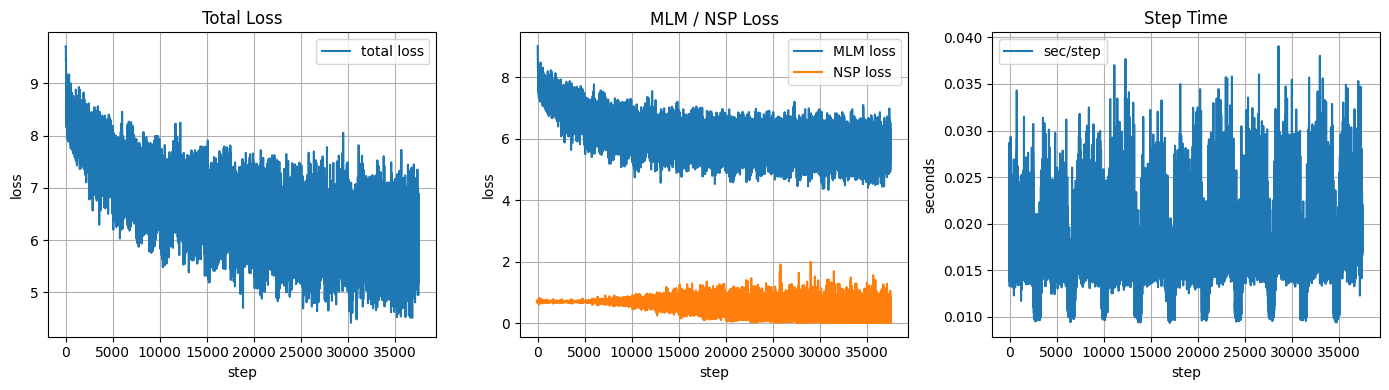

In [139]:
# ------------------------------------------------------------
# 7-1. 학습 과정 시각화
# ------------------------------------------------------------

def plot_pretrain_history(history):
    steps = history["step"]

    plt.figure(figsize=(14, 4))

    plt.subplot(1, 3, 1)
    plt.plot(steps, history["loss"], label="total loss")
    plt.xlabel("step")
    plt.ylabel("loss")
    plt.title("Total Loss")
    plt.grid(True)
    plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(steps, history["loss_mlm"], label="MLM loss")
    plt.plot(steps, history["loss_nsp"], label="NSP loss")
    plt.xlabel("step")
    plt.ylabel("loss")
    plt.title("MLM / NSP Loss")
    plt.grid(True)
    plt.legend()

    plt.subplot(1, 3, 3)
    plt.plot(steps, history["step_time"], label="sec/step")
    plt.xlabel("step")
    plt.ylabel("seconds")
    plt.title("Step Time")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()


plot_pretrain_history(history)


In [140]:
def moving_average(values, window=100):
    values = np.array(values)
    if len(values) < window:
        return values
    return np.convolve(values, np.ones(window) / window, mode="valid")

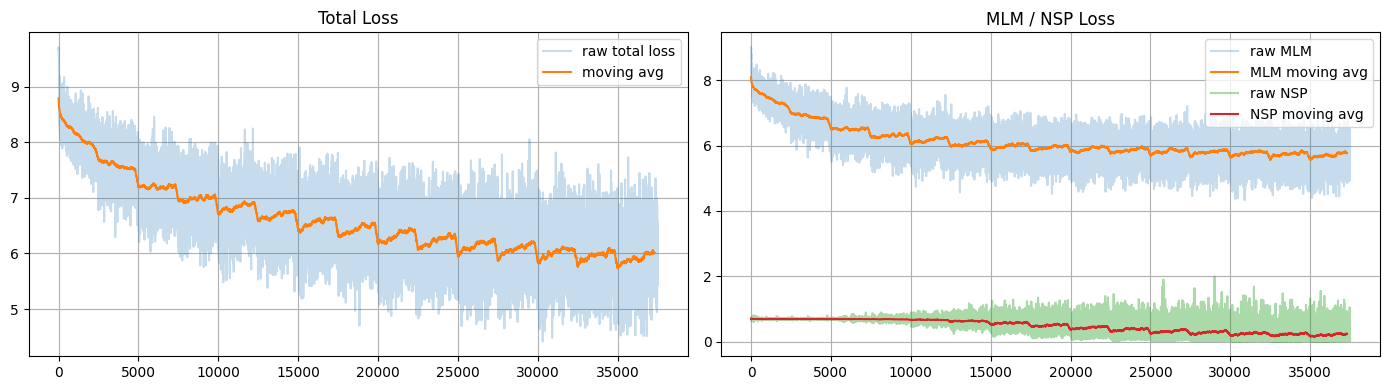

In [141]:
plt.figure(figsize=(14, 4))

plt.subplot(1, 2, 1)
plt.plot(history["loss"], alpha=0.25, label="raw total loss")
plt.plot(moving_average(history["loss"], 200), label="moving avg")
plt.title("Total Loss")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history["loss_mlm"], alpha=0.25, label="raw MLM")
plt.plot(moving_average(history["loss_mlm"], 200), label="MLM moving avg")
plt.plot(history["loss_nsp"], alpha=0.4, label="raw NSP")
plt.plot(moving_average(history["loss_nsp"], 200), label="NSP moving avg")
plt.title("MLM / NSP Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


- 학습 과정의 batch 단위 loss는 변동성이 크기 때문에 이동평균을 함께 시각화하였다. Total loss와 MLM loss는 학습 초반부터 점진적으로 감소하였으며, MLM loss는 약 7.8에서 5.8 수준까지 감소하였다. NSP loss 역시 초기에는 랜덤 이진 분류 기준인 0.69에 가까웠으나 후반으로 갈수록 약 0.4~0.5 수준으로 감소하였다. 이를 통해 MLM과 NSP pretrain task가 모두 학습되고 있음을 확인하였다.
- 정상 학습. MLM은 안정적으로 감소, NSP도 후반에 의미 있게 감소. 후반 MLM은 약간 포화.

In [142]:
# 정확도
def evaluate_pretrain_accuracy(
    model,
    metadata,
    batch_size=32,
    max_batches=None,
    device=None
):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    dataset = BertPretrainMemmapDataset(metadata)

    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0
    )

    loss_mlm_fn = nn.CrossEntropyLoss(ignore_index=-100)
    loss_nsp_fn = nn.CrossEntropyLoss()

    model.eval()

    total_loss = 0.0
    total_mlm_loss = 0.0
    total_nsp_loss = 0.0

    total_mlm_correct = 0
    total_mlm_count = 0

    total_nsp_correct = 0
    total_nsp_count = 0

    used_batches = 0

    with torch.no_grad():
        for batch_idx, batch in enumerate(tqdm(dataloader, desc="Evaluating")):
            if max_batches is not None and batch_idx >= max_batches:
                break

            input_ids = batch["input_ids"].to(device)
            segment_ids = batch["segment_ids"].to(device)
            label_mlm = batch["label_mlm"].to(device)
            label_nsp = batch["label_nsp"].to(device)

            logits_mlm, logits_nsp = model(input_ids, segment_ids)

            loss_mlm = loss_mlm_fn(
                logits_mlm.reshape(-1, config.n_vocab),
                label_mlm.reshape(-1)
            )

            loss_nsp = loss_nsp_fn(
                logits_nsp,
                label_nsp
            )

            loss = loss_mlm + loss_nsp

            total_loss += loss.item()
            total_mlm_loss += loss_mlm.item()
            total_nsp_loss += loss_nsp.item()

            # MLM accuracy: mask 위치(label_mlm != -100)만 평가
            pred_mlm = torch.argmax(logits_mlm, dim=-1)
            mlm_mask = label_mlm != -100

            total_mlm_correct += (
                pred_mlm[mlm_mask] == label_mlm[mlm_mask]
            ).sum().item()

            total_mlm_count += mlm_mask.sum().item()

            # NSP accuracy
            pred_nsp = torch.argmax(logits_nsp, dim=-1)

            total_nsp_correct += (
                pred_nsp == label_nsp
            ).sum().item()

            total_nsp_count += label_nsp.size(0)

            used_batches += 1

    result = {
        "loss": total_loss / used_batches,
        "mlm_loss": total_mlm_loss / used_batches,
        "nsp_loss": total_nsp_loss / used_batches,
        "mlm_accuracy": total_mlm_correct / max(total_mlm_count, 1),
        "nsp_accuracy": total_nsp_correct / max(total_nsp_count, 1),
        "mlm_correct": total_mlm_correct,
        "mlm_total": total_mlm_count,
        "nsp_correct": total_nsp_correct,
        "nsp_total": total_nsp_count,
    }

    return result


In [143]:
eval_result = evaluate_pretrain_accuracy(
    model=model,
    metadata=metadata,
    batch_size=32,
    max_batches=None,
    device=device
)

eval_result


Evaluating:   0%|          | 0/625 [00:00<?, ?it/s]

{'loss': 5.49404182510376,
 'mlm_loss': 5.420749073028564,
 'nsp_loss': 0.07329274706840515,
 'mlm_accuracy': 0.21509285901124772,
 'nsp_accuracy': 0.9752,
 'mlm_correct': 41115,
 'mlm_total': 191150,
 'nsp_correct': 19504,
 'nsp_total': 20000}

- 정확도 측정 결과

  ```
  10 epoch
  loss         : 5.8446
  MLM loss     : 5.5577
  NSP loss     : 0.2869
  MLM accuracy : 20.21%
  NSP accuracy : 90.68%

  15 epoch
  loss         : 5.4940
  MLM loss     : 5.4207
  NSP loss     : 0.0733
  MLM accuracy : 21.51%
  NSP accuracy : 97.52%
  ```

  - MLM
    - 20.21% → 21.51%
    - 소폭 개선
    - vocab 8007 기준으로는 train accuracy가 꽤 의미 있음

  - NSP
    - 90.68% → 97.52%
    - train set에서는 매우 잘 맞춤
    - 하지만 직접 만든 무관 문장 "대한민국 → 바나나"도 True로 예측
    - 일반화보다는 train set 패턴 적응/**과적합 가능성**



### 7-2. MLM / NSP  예측 결과

In [144]:
# ------------------------------------------------------------
# 1. MLM 예측 확인 함수
# ------------------------------------------------------------

def predict_mask(model, vocab, text, top_k=10, device=None):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model.eval()

    tokens = ["[CLS]"] + vocab.encode_as_pieces(text) + ["[SEP]"]

    if "[MASK]" not in tokens:
        raise ValueError("text 안에 [MASK]가 포함되어 있어야 합니다.")

    input_ids = torch.tensor(
        [[vocab.piece_to_id(token) for token in tokens]],
        dtype=torch.long
    ).to(device)

    segment_ids = torch.zeros_like(input_ids).to(device)

    mask_idx = tokens.index("[MASK]")

    with torch.no_grad():
        logits_mlm, logits_nsp = model(input_ids, segment_ids)

    probs = torch.softmax(logits_mlm[0, mask_idx], dim=-1)
    top_probs, top_ids = torch.topk(probs, k=top_k)

    print("input:")
    print(text)

    print("\ntokens:")
    print(tokens)

    print("\n[MASK] prediction:")
    for prob, token_id in zip(top_probs, top_ids):
        piece = vocab.id_to_piece(int(token_id))
        print(f"{piece:15s} {float(prob):.4f}")


In [145]:
predict_mask(
    model,
    vocab,
    "대한민국의 수도는 [MASK]이다.",
    top_k=10,
    device=device
)


input:
대한민국의 수도는 [MASK]이다.

tokens:
['[CLS]', '▁대한민국의', '▁수도', '는', '▁', '[MASK]', '이다', '.', '[SEP]']

[MASK] prediction:
▁문서             0.0223
▁출신             0.0148
이다              0.0110
▁성우             0.0106
의               0.0086
역               0.0082
가               0.0077
▁항목             0.0072
은               0.0071
▁참조             0.0067


In [146]:
predict_mask(
    model,
    vocab,
    "서울은 대한민국의 [MASK]이다.",
    top_k=10,
    device=device
)


input:
서울은 대한민국의 [MASK]이다.

tokens:
['[CLS]', '▁서울', '은', '▁대한민국의', '▁', '[MASK]', '이다', '.', '[SEP]']

[MASK] prediction:
▁출신             0.0166
▁대한민국의          0.0158
동               0.0132
이다              0.0123
역               0.0118
정               0.0110
번               0.0106
▁역              0.0100
철               0.0095
장               0.0092


In [147]:
# ------------------------------------------------------------
# 2. NSP 예측 확인 함수
# ------------------------------------------------------------

def predict_nsp(model, vocab, sentence_a, sentence_b, n_seq=128, device=None):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model.eval()

    tokens, segment = create_bert_input_for_nsp(
        vocab=vocab,
        sentence_a=sentence_a,
        sentence_b=sentence_b,
        n_seq=n_seq
    )

    input_ids = torch.tensor(
        [[vocab.piece_to_id(token) for token in tokens]],
        dtype=torch.long
    ).to(device)

    segment_ids = torch.tensor(
        [segment],
        dtype=torch.long
    ).to(device)

    with torch.no_grad():
        logits_mlm, logits_nsp = model(input_ids, segment_ids)

    probs = torch.softmax(logits_nsp[0], dim=-1)

    print("sentence_a:", sentence_a)
    print("sentence_b:", sentence_b)
    print("\nNSP probabilities:")
    print("False:", float(probs[0]))
    print("True :", float(probs[1]))

    pred = int(torch.argmax(probs).item())
    print("prediction:", "True" if pred == 1 else "False")


In [148]:
predict_nsp(
    model,
    vocab,
    "대한민국은 동아시아에 위치한 나라이다.",
    "수도는 서울특별시이다.",
    device=device
)


sentence_a: 대한민국은 동아시아에 위치한 나라이다.
sentence_b: 수도는 서울특별시이다.

NSP probabilities:
False: 0.007602396886795759
True : 0.9923976063728333
prediction: True


In [149]:
predict_nsp(
    model,
    vocab,
    "대한민국은 동아시아에 위치한 나라이다.",
    "바나나는 노란색 과일로 알려져 있다.",
    device=device
)


sentence_a: 대한민국은 동아시아에 위치한 나라이다.
sentence_b: 바나나는 노란색 과일로 알려져 있다.

NSP probabilities:
False: 0.03641943633556366
True : 0.9635806083679199
prediction: True


- **4096개 학습 결과 정리**
  - BERT_PRETRAIN_COUNT=4096, epochs=10 기준으로 보면 학습 정상 진행
  - 학습 로그 기준:
    ```
    Total loss: 8.6238 → 5.3408
    MLM loss  : 7.9280 → 4.9231
    NSP loss  : 0.6958 → 0.4176
    ```
  - 해석
    ```
    MLM
      - loss가 크게 감소했으므로 mask token 예측 학습은 진행됨
      - 20,000개 실험보다 최종 MLM loss가 더 낮음
      - 하지만 이는 데이터가 적어 같은 샘플을 여러 번 반복해서 본 효과가 큼
      - 작은 train set에 더 강하게 적응한 결과로 볼 수 있음

    NSP
      - 초반에는 0.69 근처로 랜덤 이진 분류 수준
      - 후반에는 0.42까지 감소하여 NSP 관계 학습이 일부 진행됨
      - 테스트에서는 관련 문장쌍을 True, 무관 문장쌍을 False로 잘 예측한 사례가 있었음

    주의점
      - 4,096개는 빠른 실행/검증용 데이터셋에 가까움
      - loss는 더 낮게 나왔지만, 일반화 관점에서는 20,000개 실험이 더 신뢰할 만함
    ```
  - 결론
    - 4,096개의 pretrain instance로 10 epoch 학습한 결과, total loss는 8.62에서 5.34로 감소하였다.
    - MLM loss는 7.93에서 4.92로 감소하였고, NSP loss는 0.70에서 0.42 수준으로 감소하였다.
    - 이는 MLM과 NSP pretrain task가 모두 학습되었음을 보여준다.
    - 다만 4,096개 데이터셋은 크기가 작아 동일한 데이터를 반복 학습하는 효과가 크므로, 최종 성능 해석에는 더 큰 20,000개 데이터셋 결과를 확인해 보아야겠다.

- **20,000개/ 10 Epoch 학습 결과 정리**

  - BERT_PRETRAIN_COUNT=20000, epochs=10 기준으로 보면 학습은 정상

  - 학습 로그 기준:
    ```
    Total loss: 8.1807 → 6.2734
    MLM loss  : 7.4868 → 5.8139
    NSP loss  : 0.6939 → 0.4595
    ```
  - 해석
    ```
    MLM
      - loss가 확실히 감소했으므로 mask token 예측 학습은 진행됨
      - 다만 직접 넣은 "대한민국의 수도는 [MASK]이다" 같은 지식형 예측은 아직 약함
      - top prediction이 "서울"이 아니라 "▁문서", "이다", "▁항목" 등 빈도 높은 나무위키식 토큰으로 나옴

    NSP
      - 관련 문장쌍 "대한민국 → 수도 서울특별시"는 True 0.91로 잘 맞춤
      - 하지만 무관 문장쌍 "대한민국 → 바나나"도 True 0.63으로 예측
      - 문장 관계를 일부 학습했지만, 일반화는 아직 불안정함
    ```
  - 결론
    - 20,000개의 pretrain instance로 10 epoch 학습한 결과, total loss는 8.18에서 6.27로 감소하였다.
    - MLM loss는 7.49에서 5.81로 감소하여 mask token 예측 학습이 진행되었음을 확인하였다.
    - NSP loss는 초기 0.69 수준에서 최종 0.46으로 감소하여 문장 pair 관계 학습도 일부 이루어졌다.
    - 다만 MLM 예측에서는 의미 지식보다 빈도 높은 토큰이 우선 출력되었고, NSP에서도 일부 무관 문장쌍을 True로 예측하여 제한된 데이터와 작은 모델 크기의 한계를 확인하였다

- **20,000개/ 15 Epoch 학습 결과 정리**

  - BERT_PRETRAIN_COUNT=20000, epochs=15 기준으로 보면 학습은 정상
  - 학습 로그 기준:
    ```
      20,000 / 10 epoch
        Total loss: 6.2734
        MLM loss  : 5.8139
        NSP loss  : 0.4595

      20,000 / 15 epoch
        Total loss: 5.9051
        MLM loss  : 5.6987
        NSP loss  : 0.2064
    ```
  - 해석
    ```
      Total loss
        - 6.27 → 5.91
        - 추가 학습 효과 있음

      MLM loss
        - 5.81 → 5.70
        - 소폭 개선
        - 10 epoch 이후에는 많이 줄지는 않음

      NSP loss
        - 0.46 → 0.21
        - 크게 개선
        - train set 기준 NSP를 상당히 잘 맞추는 상태
    ```
  - 결론
    - 20,000개의 pretrain instance에 대해 15 epoch 학습한 결과, total loss는 8.19에서 5.91로 감소하였다.
    - MLM loss는 7.49에서 5.70으로 감소하여 mask token 예측 학습이 지속적으로 이루어졌고, NSP loss는 0.69에서 0.21로 크게 감소하였다.
    - 10 epoch 결과와 비교했을 때 MLM loss는 소폭 개선되었고 NSP loss는 크게 개선되었다.
    - loss 수치는 감소추세로 더 좋아졌으나, NSP의 경우 상당히 높은 정확도에도 불구하고, 샘플 테스트에서 무관한 문장쌍에 대해서도 높은 True 확률을 출력하는 결과가 나타났다.
    - 이는 반복 학습으로 인해 NSP head가 train set 패턴에 과적합되었을 가능성을 보여준다


## Step 8. 회고

이번 프로젝트에서는 나무위키 기반 corpus를 사용해 SentencePiece tokenizer를 학습하고, MLM과 NSP를 동시에 수행하는 mini BERT pretrain pipeline을 구현하였다. 전체 파이프라인은 tokenizer 생성, MLM mask 생성, NSP pair 생성, jsonl/memmap 데이터셋 구성, 약 1M parameter BERT 모델 학습까지 정상적으로 연결되었다.

정확도를 높이는 것이 어려웠던 가장 큰 이유는 모델 크기와 데이터 규모의 제한이다. vocab size는 8007인데 모델은 약 1.03M parameter로 매우 작기 때문에, 다양한 문맥에서 mask token을 정확히 예측하기에는 표현력이 부족하다. 또한 MLM은 8007개 token 중 하나를 맞히는 문제라 NSP보다 훨씬 어렵다. NSP의 경우 train accuracy는 높게 나왔지만, 직접 만든 무관한 문장쌍에서도 True로 예측하는 사례가 있어 train set의 negative sampling 패턴에 과적합되었을 가능성이 있다.

정확도를 더 높이려면 pretrain instance 수를 20,000개보다 더 늘리거나, epoch 수를 조절하면서 validation set 기준 성능을 확인해볼 수 있다. 또 NSP negative pair를 단순 랜덤 문장 대신 주제가 명확히 다른 문서에서 뽑도록 개선하면 문장 관계 판단 성능이 더 좋아질 수 있다. MLM 쪽은 tokenizer 품질, corpus 크기, 모델 hidden size, layer 수가 영향을 주지만, parameter 1M 제한이 있어 무작정 모델을 키우기는 어렵다.

정확도가 올라간다고 해서 반드시 “대한민국의 수도는 [MASK]이다 → 서울” 같은 샘플 테스트가 바로 잘 나오는 것은 아니다. 현재 학습은 작은 mini BERT의 pretrain sanity check에 가깝고, 특정 지식형 문장을 맞히려면 훨씬 큰 corpus, 더 긴 학습, 더 큰 모델이 필요하다. 특히 MLM accuracy가 올라가도 모델은 자주 등장하는 일반 token을 우선 예측할 수 있어, 사람이 기대하는 의미 기반 답변과 다를 수 있다.

추가 실험으로는 1) train/validation split을 만들어 일반화 성능 확인, 2) pretrain count를 50,000 이상으로 증가, 3) NSP negative sampling 방식 개선, 4) parameter 1M 조건 안에서 d_model, n_layer, d_ff 조합 비교를 해볼 수 있다.

